# What Makes a StarCraft II Player Skilled?

### A regression study of 3,300 ranked players, told twice — once with the wrong tool, once with the right one.

**Arrington Walters** &middot; original December 2020, ordinal extension 2026

---

## TL;DR

Player rank in StarCraft II ranges Bronze → Grandmaster across seven discrete leagues. That makes the response variable **ordinal**, which complicates regression — the spacing between Silver and Gold is not necessarily the same as the spacing between Master and Grandmaster.

The original report (a STAT 757 final) treats rank as continuous and fits an OLS model. It works, but the assumptions are violated, and the predictions cannot stay inside the league grid. The 2026 extension refits the same problem with a **cumulative link model** (CLM) — the regression model actually designed for ordinal responses — and answers the question properly.

| Model | Tool | In-sample accuracy | Within-1 league | Mean abs. error |
|-------|------|--------------------|------------------|------------------|
| Base-rate guess | (none) | 19% | &mdash; | &mdash; |
| `lm_omega` (backward OLS) | `statsmodels.OLS` | 35% | &mdash; | &mdash; |
| `lm_stepwise` (best-subset OLS) | `statsmodels.OLS` | 40% | 88% | 0.73 |
| **`ord_final` (CLM, probit, 10 predictors)** | **`statsmodels.OrderedModel`** | **43%** | **88%** | **0.70** |
| 5-fold CV mean | (validation) | 43% | 88% | 0.70 |

**The interesting finding isn't the accuracy bump — it's that the ordinal model misses by a single league when it misses at all.** That is the property an OLS rounding hack cannot give you.

If you want the headline takeaway for aspiring players: **APM is a follower, not a leader**. Once you control for confounding, the predictors that move rank most are **ActionLatency** (how fast you act once you focus on something), **TotalHours**, and **MinimapAttacks** (commanding off-screen). Speed of execution emerges from those habits, not the other way around.

---


In [1]:
import warnings, itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.special import expit

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.miscmodels.ordinal_model import OrderedModel

from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, mean_absolute_error

# Visual identity — matches the StarCraft II league icon colours
LEAGUE_PAL = ["#CC6600", "#999999", "#FFCC00", "#CCCFFF",
              "#CCFFFF", "#0072B2", "#FF6600"]
LEAGUE_LBL = ["Bronze", "Silver", "Gold", "Platinum",
              "Diamond", "Master", "Grandmaster"]

sns.set_theme(style="whitegrid", font_scale=0.95,
              rc={"axes.facecolor": "white", "figure.facecolor": "white",
                  "axes.edgecolor": ".3", "grid.color": ".92"})
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 120,
                      "font.family": "sans-serif"})


# Introduction

Videogames are one of my favorite pastimes. As a player who participates in ranked play, I've always kept my eye on the forefront of global competitions. One of the most notable games to establish an international competitive scene backed by paid professionals was the real-time strategy game (RTS) StarCraft II (SC2). In 2013 the top 10 StarCraft players made nearly four million dollars from their combined winnings. Watching top-caliber players' reflexes and control is astonishing to even seasoned videogame enthusiasts. At the 2019 StarCraft II World Championship Finale, many others and I packed into the arena to see what these professionals could do firsthand.

![WCS](./inline/WCS.png)

The eye-watering speeds they perform at is universally referenced in gaming terminology as actions per minute (APMs). Professionals take actions at such fast speeds (high APMs); it becomes challenging to follow their overall strategy. Past pondering their sheer speed, I found it difficult to distinctly define what made these players highly skilled.

To learn more about what defines talent in SC2, we will explore in-game metrics to explain rank in competitive mode. The dataset was provided by [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/SkillCraft1+Master+Table+Dataset).

## Goal

To model the response **LeagueIndex**, a sample of player data from a 2013 ranked season of StarCraft II will be explored. The modeling process will consider all the predictor variables and then trim down until only significant predictors remain. Variables will be vetted for multicollinearity, and finally, the model will be explored to see if the BLUE assumptions hold.

The goal of this analysis will be to test the explanatory power of APMs and other predictors that are less commonly discussed.

## Limitations of the Model

The multivariate regression model used for the midterm portion of this study explores the linear estimation of the mean response of **LeagueIndex** estimated by predictors in the design matrix $X$.

The assumptions of this model's explanatory power depend on the residual error being Gaussian. Considering **LeagueIndex** is an ordinal variable, it is doubtful, if not impossible, for the residuals to be statistically normal.

A more suitable form of a model for this regression would be based on a Polytomous Logistic Regression for Ordinal Response (Proportional Odds Model). These methods will be revisited in the extension.


# Data Exploration

In [2]:
sc = pd.read_csv("SkillCraft1_Dataset.csv")
print("Shape:", sc.shape)
print("Columns:", list(sc.columns))


Shape: (3395, 20)
Columns: ['GameID', 'LeagueIndex', 'Age', 'HoursPerWeek', 'TotalHours', 'APM', 'SelectByHotkeys', 'AssignToHotkeys', 'UniqueHotkeys', 'MinimapAttacks', 'MinimapRightClicks', 'NumberOfPACs', 'GapBetweenPACs', 'ActionLatency', 'ActionsInPAC', 'TotalMapExplored', 'WorkersMade', 'UniqueUnitsMade', 'ComplexUnitsMade', 'ComplexAbilitiesUsed']


The dataset is a sample of averaged in-game metrics of StarCraft II players who participated in 2013 ranked play.

**LeagueIndex** — The levels range 1–8 corresponding to player ranks Bronze, Silver, Gold, Platinum, Diamond, Master, Grandmaster, and Professional. The rating system is similar to an Elo system, whose errors follow an extreme-value (Gumbel) distribution. Unfortunately, finer subdivisions are unavailable, so we are limited to predicting this ordinal response.

![Leagues](./inline/StarCraft-II-Leagues.png)

**Actions Per Minute (APMs)** — the standard metric for analyzing proficiency of players at RTS games; it is theorized that skills like this provide a great advantage.

**Perception-Action Cycles (PACs)** — the circular flow of information between an organism and its environment where a sensor-guided sequence of behaviors is iteratively followed towards a goal. In this dataset, PACs are aggregates of screen movements where a PAC is a screen fixation containing at least one action.


# Data Cleaning

In [3]:
# Force numeric — some columns read as object due to '?' placeholders
for col in ["HoursPerWeek", "TotalHours", "Age"]:
    sc[col] = pd.to_numeric(sc[col], errors="coerce")

n_pro   = (sc.LeagueIndex == 8).sum()
n_na_age = sc.Age.isna().sum()
print(f"Missing Age values: {n_na_age}  (all {n_pro} professionals)")

# Drop professionals — this study targets how average players become good,
# not how the elite become the best. Also fixes the Age NAs.
sc = sc[sc.LeagueIndex != 8].copy()

# Drop the outlier with 1,000,000 TotalHours (≈114 years of game time)
sc = sc[sc.TotalHours < 1_000_000].copy()

# Drop remaining NAs and zero-hour-per-week rows
sc = sc.dropna().query("HoursPerWeek > 0").copy()
print(f"Clean shape: {sc.shape}")


Missing Age values: 55  (all 55 professionals)
Clean shape: (3336, 20)


## Converting Units

Some time-averaged metrics are per SC2 timestamp (~88.5 timestamps/second) while others are per millisecond. All will be converted to per-second to aid interpretability. This transformation is linear and does not affect model assumptions.


In [4]:
ts_cols = ["NumberOfPACs", "MinimapAttacks", "MinimapRightClicks",
           "SelectByHotkeys", "AssignToHotkeys", "UniqueHotkeys",
           "WorkersMade", "UniqueUnitsMade", "ComplexUnitsMade",
           "ComplexAbilitiesUsed"]
for c in ts_cols:
    sc[c] = sc[c] * 88.5

ms_cols = ["GapBetweenPACs", "ActionLatency"]
for c in ms_cols:
    sc[c] = sc[c] * 1000


## Summary Statistics and Plots

### Gaussianity of the Response

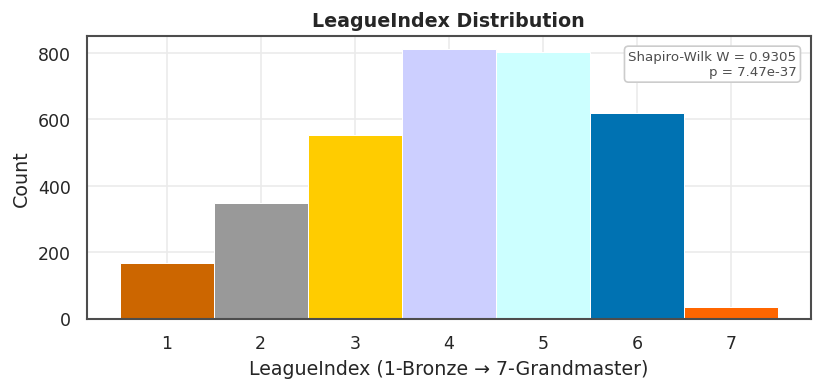

Mean LeagueIndex: 4.12


In [5]:
stat, pval = stats.shapiro(sc.LeagueIndex)

fig, ax = plt.subplots(figsize=(7, 3.4))
counts, bins, patches = ax.hist(sc.LeagueIndex, bins=np.arange(0.5, 8.5, 1),
                                 edgecolor="white", linewidth=0.6)
for patch, color in zip(patches, LEAGUE_PAL):
    patch.set_facecolor(color)
ax.set_xlabel("LeagueIndex (1-Bronze → 7-Grandmaster)")
ax.set_ylabel("Count")
ax.set_title("LeagueIndex Distribution",
             fontweight="bold")
ax.text(0.98, 0.95,
        f"Shapiro-Wilk W = {stat:.4f}\np = {pval:.2e}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=8, color="0.30",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.80"))
plt.tight_layout()
plt.show()
print(f"Mean LeagueIndex: {sc.LeagueIndex.mean():.2f}")


### Correlation Plot

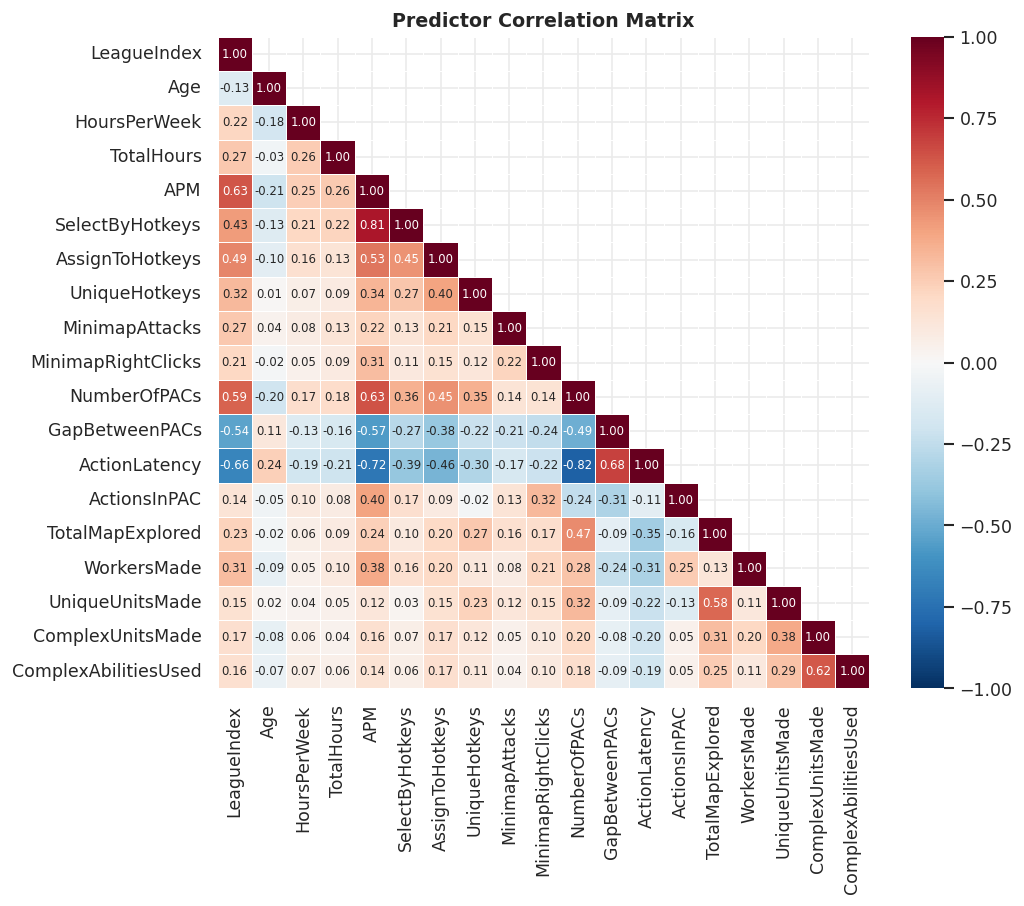

In [6]:
sc_numeric = sc.select_dtypes(include="number").drop(columns=["GameID"])
corr = sc_numeric.corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            annot_kws={"size": 7}, ax=ax, square=True)
ax.set_title("Predictor Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.show()


In [7]:
# Store full data before dropping confounders (needed for Final section)
sc_n = sc.copy()

# Drop columns that confound with APM-family metrics
drop_cols = ["GameID", "ActionLatency", "GapBetweenPACs",
             "NumberOfPACs", "SelectByHotkeys", "ActionsInPAC"]
sc = sc.drop(columns=drop_cols)
print("Remaining predictors:", [c for c in sc.columns if c != "LeagueIndex"])


Remaining predictors: ['Age', 'HoursPerWeek', 'TotalHours', 'APM', 'AssignToHotkeys', 'UniqueHotkeys', 'MinimapAttacks', 'MinimapRightClicks', 'TotalMapExplored', 'WorkersMade', 'UniqueUnitsMade', 'ComplexUnitsMade', 'ComplexAbilitiesUsed']


### Visual Trend Analysis

Violin plots gauge the linearity with respect to the response and the distribution at each level. They are preferred over scatter plots when the response is ordinal.


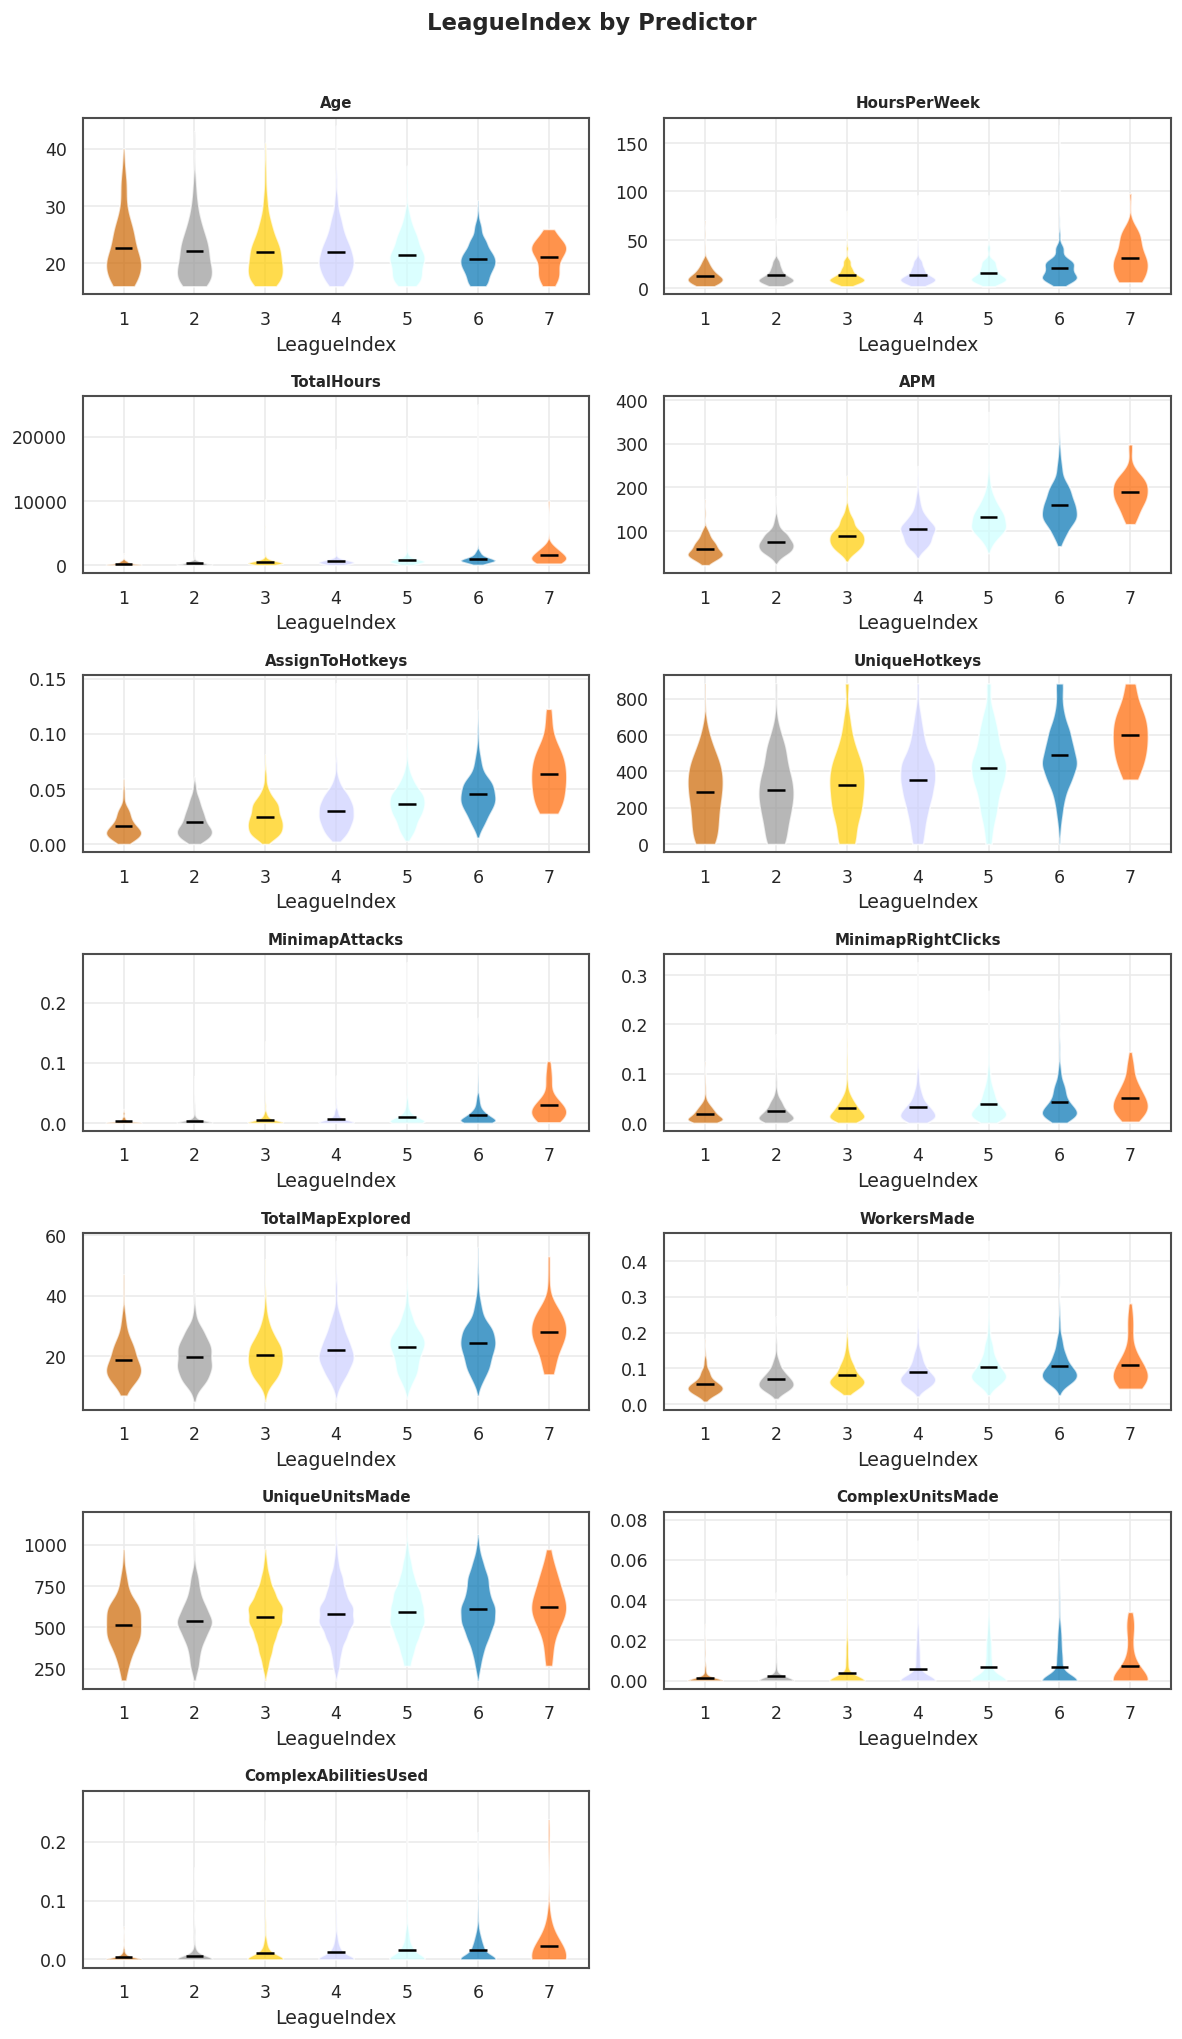

In [8]:
preds = [c for c in sc.columns if c != "LeagueIndex"]
ncols = 2
nrows = int(np.ceil(len(preds) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 2.4))
axes = axes.flatten()

for i, pred in enumerate(preds):
    parts = axes[i].violinplot(
        [sc.loc[sc.LeagueIndex == lv, pred].values for lv in range(1, 8)],
        positions=range(1, 8), showmeans=True, showextrema=False)
    for j, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(LEAGUE_PAL[j])
        pc.set_alpha(0.7)
    parts["cmeans"].set_color("black")
    axes[i].set_title(pred, fontweight="bold", fontsize=9)
    axes[i].set_xlabel("LeagueIndex")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("LeagueIndex by Predictor", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


# Model Specifications

## Multivariate Regression: Manual Backward Selection ($lm_\Omega$ to $lm_\omega$)

A model with all predictors will be built. Subsequently, predictors will be dropped one-by-one until only predictors with significance of at least $\alpha = 5\%$ remain.


In [9]:
y = sc["LeagueIndex"]
X_all = sm.add_constant(sc.drop(columns=["LeagueIndex"]))

lm_omega = sm.OLS(y, X_all).fit()
print("=== lm_Ω (all predictors) ===")
print(lm_omega.summary2().tables[1].to_string())


=== lm_Ω (all predictors) ===
                          Coef.  Std.Err.          t          P>|t|     [0.025     0.975]
const                  1.460919  0.136637  10.691980   2.952023e-26   1.193018   1.728820
Age                   -0.002291  0.004577  -0.500592   6.166916e-01  -0.011265   0.006682
HoursPerWeek           0.005111  0.001644   3.109141   1.892211e-03   0.001888   0.008334
TotalHours             0.000165  0.000023   7.246166   5.305613e-13   0.000121   0.000210
APM                    0.012324  0.000526  23.448448  1.202710e-112   0.011294   0.013355
AssignToHotkeys       13.422418  1.232264  10.892486   3.585248e-27  11.006345  15.838492
UniqueHotkeys          0.000473  0.000101   4.670908   3.117607e-06   0.000275   0.000672
MinimapAttacks        11.197624  1.385348   8.082893   8.768999e-16   8.481401  13.913847
MinimapRightClicks    -0.775561  0.624925  -1.241047   2.146762e-01  -2.000838   0.449716
TotalMapExplored       0.005903  0.003135   1.883129   5.977013e-02  -

In [10]:
# Iterative backward elimination by worst p-value
def backward_select(y, X, alpha=0.05):
    """Drop worst p-value predictor until all significant."""
    steps = []
    while True:
        model = sm.OLS(y, X).fit()
        pvals = model.pvalues.drop("const", errors="ignore")
        worst = pvals.idxmax()
        if pvals[worst] <= alpha:
            break
        X = X.drop(columns=[worst])
        steps.append(worst)
    return model, steps

lm_final, dropped = backward_select(y, X_all.copy())
print("Dropped (in order):", dropped)
print()
print("=== lm_ω (final) ===")
summary = pd.DataFrame({
    "coef": lm_final.params,
    "std err": lm_final.bse,
    "t": lm_final.tvalues,
    "P>|t|": lm_final.pvalues,
    "CI low": lm_final.conf_int()[0],
    "CI high": lm_final.conf_int()[1],
})
print(summary.to_string(float_format="%.4f"))


Dropped (in order): ['UniqueUnitsMade', 'Age', 'ComplexUnitsMade', 'MinimapRightClicks']

=== lm_ω (final) ===
                        coef  std err       t  P>|t|  CI low  CI high
const                 1.4063   0.0721 19.5164 0.0000  1.2651   1.5476
HoursPerWeek          0.0053   0.0016  3.2616 0.0011  0.0021   0.0085
TotalHours            0.0002   0.0000  7.2174 0.0000  0.0001   0.0002
APM                   0.0122   0.0005 24.1408 0.0000  0.0112   0.0132
AssignToHotkeys      13.5231   1.2304 10.9907 0.0000 11.1106  15.9355
UniqueHotkeys         0.0005   0.0001  4.6899 0.0000  0.0003   0.0007
MinimapAttacks       10.8572   1.3612  7.9760 0.0000  8.1883  13.5261
TotalMapExplored      0.0064   0.0027  2.3922 0.0168  0.0012   0.0117
WorkersMade           2.7162   0.4332  6.2707 0.0000  1.8669   3.5655
ComplexAbilitiesUsed  1.9226   0.8167  2.3541 0.0186  0.3213   3.5238


### Assessing Fit and Overall Significance

$$H_0: \beta = 0 \quad\text{vs}\quad H_a: \text{LeagueIndex} = X\beta + \epsilon$$


In [11]:
print(f"lm_Ω  adj-R² = {lm_omega.rsquared_adj:.4f}  F p-value ≈ {lm_omega.f_pvalue:.2e}")
print(f"lm_ω  adj-R² = {lm_final.rsquared_adj:.4f}  F p-value ≈ {lm_final.f_pvalue:.2e}")

# ANOVA between Ω and ω
from scipy.stats import f as f_dist
rss_o = lm_omega.ssr
rss_f = lm_final.ssr
df_diff = lm_omega.df_model - lm_final.df_model
df_resid = lm_omega.df_resid
F_stat = ((rss_f - rss_o) / df_diff) / (rss_o / df_resid)
p_anova = 1 - f_dist.cdf(F_stat, df_diff, df_resid)
print(f"\nANOVA Ω vs ω: F = {F_stat:.3f}, p = {p_anova:.4f}")
print("→ Cannot reject H₀ that the models produce comparable residuals.")


lm_Ω  adj-R² = 0.4620  F p-value ≈ 0.00e+00
lm_ω  adj-R² = 0.4622  F p-value ≈ 0.00e+00

ANOVA Ω vs ω: F = 0.651, p = 0.6262
→ Cannot reject H₀ that the models produce comparable residuals.


### Confounding: AssignToHotkeys vs APM

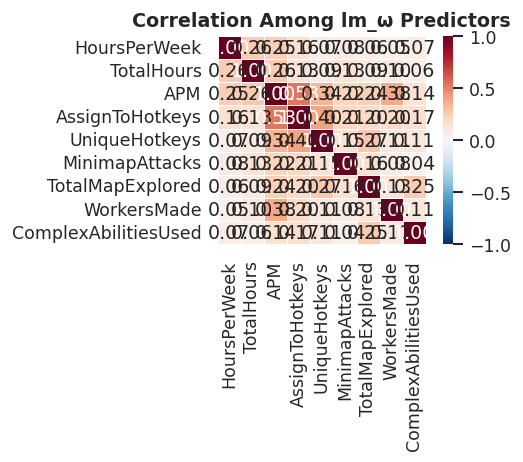

In [12]:
keep = [c for c in lm_final.model.exog_names if c != "const"]
corr_omega = sc[keep].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_omega, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax, square=True)
ax.set_title("Correlation Among lm_ω Predictors", fontweight="bold")
plt.tight_layout()
plt.show()


In [13]:
# Drop AssignToHotkeys and HoursPerWeek based on confounding analysis
cols_final = [c for c in lm_final.model.exog_names
              if c not in ("const", "AssignToHotkeys", "HoursPerWeek")]

X_rev = sm.add_constant(sc[cols_final])
lm_final = sm.OLS(y, X_rev).fit()
print("=== Revised lm_ω (after confounding remediation) ===")
summary = pd.DataFrame({
    "coef": lm_final.params, "P>|t|": lm_final.pvalues,
    "CI low": lm_final.conf_int()[0], "CI high": lm_final.conf_int()[1],
})
print(summary.to_string(float_format="%.4f"))
print(f"\nadj-R² = {lm_final.rsquared_adj:.4f}")


=== Revised lm_ω (after confounding remediation) ===
                        coef  P>|t|  CI low  CI high
const                 1.5040 0.0000  1.3635   1.6446
TotalHours            0.0002 0.0000  0.0001   0.0002
APM                   0.0148 0.0000  0.0138   0.0157
UniqueHotkeys         0.0008 0.0000  0.0006   0.0009
MinimapAttacks       12.2470 0.0000  9.5364  14.9577
TotalMapExplored      0.0065 0.0170  0.0012   0.0119
WorkersMade           2.6108 0.0000  1.7459   3.4756
ComplexAbilitiesUsed  2.8809 0.0005  1.2566   4.5052

adj-R² = 0.4409


## Structural Uncertainty and Predictions

Without cross-validation, we can see fundamental issues with the fitted values. The predictions are continuous, so they are rounded and clamped to 1–7 for comparison.


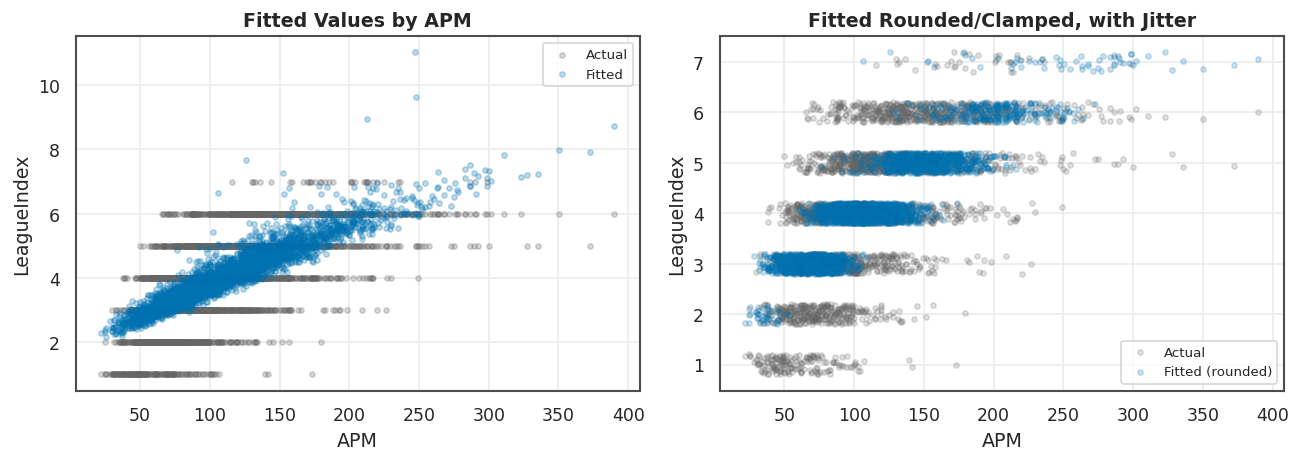

In [14]:
fitted = lm_final.fittedvalues.copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw fitted
axes[0].scatter(sc.APM, sc.LeagueIndex, alpha=0.25, s=10, label="Actual", color="0.40")
axes[0].scatter(sc.APM, fitted, alpha=0.25, s=10, label="Fitted", color="#0072B2")
axes[0].set_title("Fitted Values by APM", fontweight="bold")
axes[0].set_xlabel("APM"); axes[0].set_ylabel("LeagueIndex")
axes[0].legend(fontsize=8)

# Rounded + clamped
fitted_rnd = np.clip(np.round(fitted), 1, 7).astype(int)
jitter = lambda v: v + np.random.uniform(-0.2, 0.2, size=len(v))
axes[1].scatter(sc.APM, jitter(sc.LeagueIndex.values), alpha=0.2, s=10,
                label="Actual", color="0.40")
axes[1].scatter(sc.APM, jitter(fitted_rnd), alpha=0.2, s=10,
                label="Fitted (rounded)", color="#0072B2")
axes[1].set_title("Fitted Rounded/Clamped, with Jitter", fontweight="bold")
axes[1].set_xlabel("APM"); axes[1].set_ylabel("LeagueIndex")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


Overall lm_ω accuracy (rounded/clamped): 34.6%


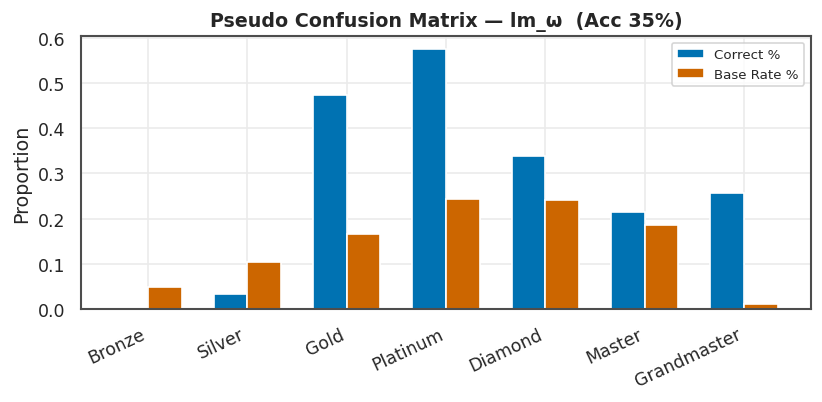

In [15]:
acc_lm = (fitted_rnd == sc.LeagueIndex.values).mean()
print(f"Overall lm_ω accuracy (rounded/clamped): {acc_lm:.1%}")

# Per-league accuracy vs base rate
fig, ax = plt.subplots(figsize=(7, 3.5))
leagues = sorted(sc.LeagueIndex.unique())
correct = [((fitted_rnd == lv) & (sc.LeagueIndex.values == lv)).sum() /
           (sc.LeagueIndex.values == lv).sum() for lv in leagues]
baserate = [(sc.LeagueIndex.values == lv).mean() for lv in leagues]

x = np.arange(len(leagues))
ax.bar(x - 0.17, correct, 0.34, label="Correct %", color="#0072B2")
ax.bar(x + 0.17, baserate, 0.34, label="Base Rate %", color="#CC6600")
ax.set_xticks(x); ax.set_xticklabels(LEAGUE_LBL[:len(leagues)], rotation=25, ha="right")
ax.set_ylabel("Proportion"); ax.legend(fontsize=8)
ax.set_title(f"Pseudo Confusion Matrix — lm_ω  (Acc {acc_lm:.0%})", fontweight="bold")
plt.tight_layout()
plt.show()


---
# Introduction to Final

The final analysis will use stepwise (exhaustive) regression and the ordinal model.
$\text{TotalHours}$ receives a log transform to reduce leverage from outliers.


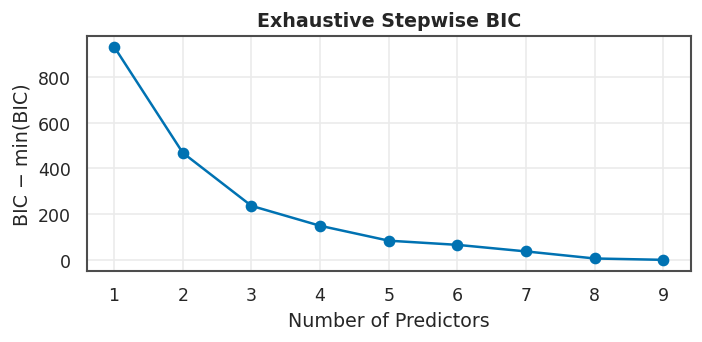

Best 5-predictor model:
['TotalHours', 'APM', 'AssignToHotkeys', 'MinimapAttacks', 'ActionLatency']


In [16]:
sc_n["TotalHours"] = np.log(sc_n["TotalHours"])

# Exhaustive best-subset selection (BIC) up to p=8 predictors
pred_all = [c for c in sc_n.columns if c not in ("GameID", "LeagueIndex")]
y_n = sc_n["LeagueIndex"]

best_bic = {}
for k in range(1, min(len(pred_all), 9) + 1):
    best = None
    for combo in itertools.combinations(pred_all, k):
        X_c = sm.add_constant(sc_n[list(combo)])
        try:
            m = sm.OLS(y_n, X_c).fit()
        except Exception:
            continue
        if best is None or m.bic < best.bic:
            best = m
    best_bic[k] = best

fig, ax = plt.subplots(figsize=(6, 3))
ks = sorted(best_bic)
bics = [best_bic[k].bic for k in ks]
bics_rel = [b - min(bics) for b in bics]
ax.plot(ks, bics_rel, "o-", color="#0072B2")
ax.set_xlabel("Number of Predictors"); ax.set_ylabel("BIC − min(BIC)")
ax.set_title("Exhaustive Stepwise BIC", fontweight="bold")
plt.tight_layout()
plt.show()

# Best 5-predictor model
best5 = best_bic[5]
print("Best 5-predictor model:")
print([c for c in best5.model.exog_names if c != "const"])


# Diagnostics

## Confounding — APM vs ActionLatency

In [17]:
sw_pred = [c for c in best5.model.exog_names if c != "const"]
X_sw = sm.add_constant(sc_n[sw_pred])
lm_sw = sm.OLS(y_n, X_sw).fit()

# VIF
vif_df = pd.DataFrame({
    "Predictor": sw_pred,
    "VIF": [variance_inflation_factor(X_sw.values, i+1) for i in range(len(sw_pred))]
}).sort_values("VIF", ascending=False)
print("=== VIF of lm_↻ ===")
print(vif_df.to_string(index=False))
print(f"\nadj-R² = {lm_sw.rsquared_adj:.3f}   BIC = {lm_sw.bic:.0f}")


=== VIF of lm_↻ ===
      Predictor      VIF
            APM 2.427931
  ActionLatency 2.169716
AssignToHotkeys 1.437736
     TotalHours 1.215505
 MinimapAttacks 1.069826

adj-R² = 0.566   BIC = 9195


In [18]:
# Remediate: force out APM, re-run exhaustive for 5 predictors
pred_no_apm = [c for c in pred_all if c != "APM"]
best5_no_apm = None
for combo in itertools.combinations(pred_no_apm, 5):
    X_c = sm.add_constant(sc_n[list(combo)])
    try:
        m = sm.OLS(y_n, X_c).fit()
    except Exception:
        continue
    if best5_no_apm is None or m.bic < best5_no_apm.bic:
        best5_no_apm = m

sw_pred_final = [c for c in best5_no_apm.model.exog_names if c != "const"]
X_sw = sm.add_constant(sc_n[sw_pred_final])
lm_sw = sm.OLS(y_n, X_sw).fit()

vif_df2 = pd.DataFrame({
    "Predictor": sw_pred_final,
    "VIF": [variance_inflation_factor(X_sw.values, i+1) for i in range(len(sw_pred_final))]
}).sort_values("VIF", ascending=False)
print("=== lm_↻ with APM forced out ===")
print(f"Predictors: {sw_pred_final}")
print(vif_df2.to_string(index=False))
print(f"\nadj-R² = {lm_sw.rsquared_adj:.3f}   BIC = {lm_sw.bic:.0f}")


=== lm_↻ with APM forced out ===
Predictors: ['TotalHours', 'SelectByHotkeys', 'AssignToHotkeys', 'MinimapAttacks', 'ActionLatency']
      Predictor      VIF
  ActionLatency 1.453455
AssignToHotkeys 1.449524
SelectByHotkeys 1.348673
     TotalHours 1.205359
 MinimapAttacks 1.062483

adj-R² = 0.563   BIC = 9217


## Gauss–Markov: Residual Normality

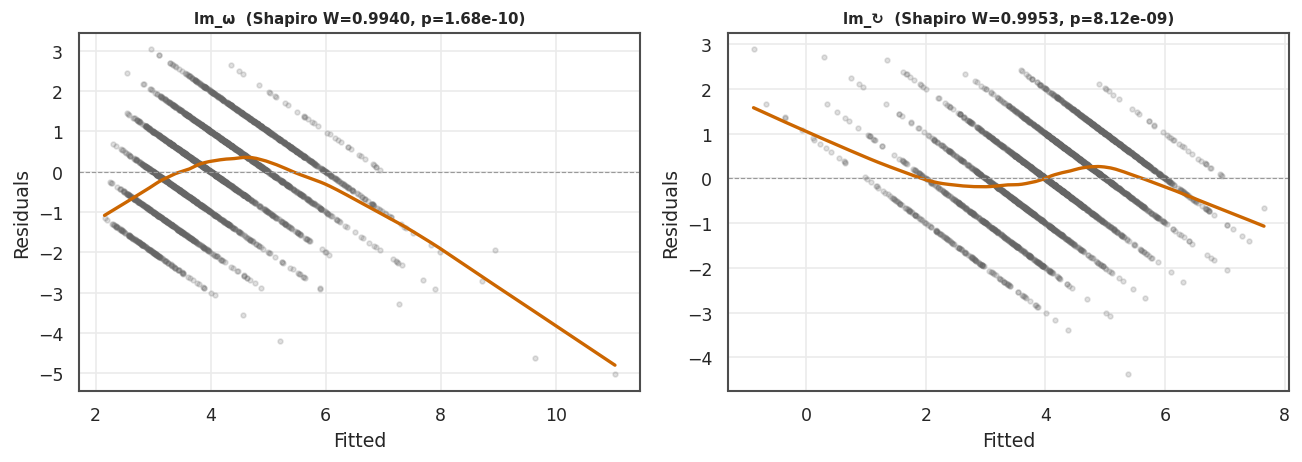

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, mdl, title in [(axes[0], lm_final, "lm_ω"),
                        (axes[1], lm_sw,    "lm_↻")]:
    resid = mdl.resid
    ax.scatter(mdl.fittedvalues, resid, alpha=0.2, s=8, color="0.40")
    lowess = sm.nonparametric.lowess(resid, mdl.fittedvalues, frac=0.3)
    ax.plot(lowess[:, 0], lowess[:, 1], color="#CC6600", lw=2)
    ax.axhline(0, color="0.60", ls="--", lw=0.7)
    ax.set_xlabel("Fitted"); ax.set_ylabel("Residuals")
    stat, p = stats.shapiro(resid[:5000])
    ax.set_title(f"{title}  (Shapiro W={stat:.4f}, p={p:.2e})", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.show()


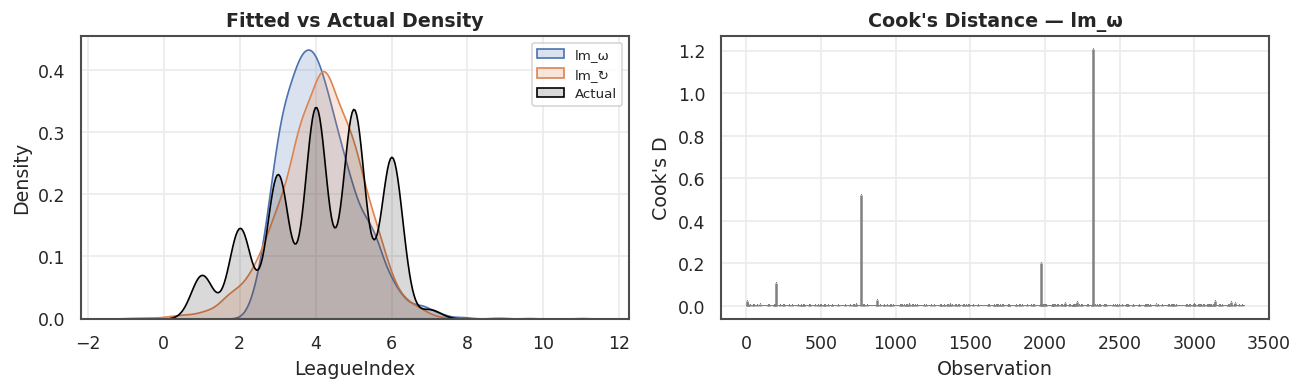

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

# Density comparison
for ax_i, mdl, lbl in [(axes[0], lm_final, "lm_ω"), (axes[0], lm_sw, "lm_↻")]:
    sns.kdeplot(mdl.fittedvalues, ax=ax_i, label=lbl, fill=True, alpha=0.2)
sns.kdeplot(y_n, ax=axes[0], label="Actual", color="black", fill=True, alpha=0.15)
axes[0].set_xlabel("LeagueIndex"); axes[0].set_title("Fitted vs Actual Density", fontweight="bold")
axes[0].legend(fontsize=8)

# Cook's distance for lm_ω
infl = lm_final.get_influence()
cooks = infl.cooks_distance[0]
axes[1].stem(range(len(cooks)), cooks, markerfmt=",", linefmt="grey",
             basefmt=" ")
axes[1].set_ylabel("Cook's D"); axes[1].set_xlabel("Observation")
axes[1].set_title("Cook's Distance — lm_ω", fontweight="bold")
plt.tight_layout()
plt.show()


# Proportional Odds Model (Original)

The ordinal package `OrderedModel` in statsmodels fits a cumulative link model using the same predictors as $lm_\circlearrowleft$.


In [21]:
# Scale predictors (NOT the response) for numerical stability
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_ord_raw = sc_n[sw_pred_final].copy()
X_ord_scaled = pd.DataFrame(scaler.fit_transform(X_ord_raw),
                            columns=sw_pred_final, index=sc_n.index)
y_ord = sc_n["LeagueIndex"].astype(int)

ord_orig = OrderedModel(y_ord, X_ord_scaled, distr="logit")
res_orig = ord_orig.fit(method="bfgs", disp=False)
print(res_orig.summary())


                             OrderedModel Results                             
Dep. Variable:            LeagueIndex   Log-Likelihood:                -4394.0
Model:                   OrderedModel   AIC:                             8810.
Method:            Maximum Likelihood   BIC:                             8877.
Date:                Sat, 09 May 2026                                         
Time:                        08:10:10                                         
No. Observations:                3336                                         
Df Residuals:                    3325                                         
Df Model:                           5                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
TotalHours          0.6976      0.038     18.328      0.000       0.623       0.772
SelectByHotkeys     0.3287      0.041

# Comparison Between Models

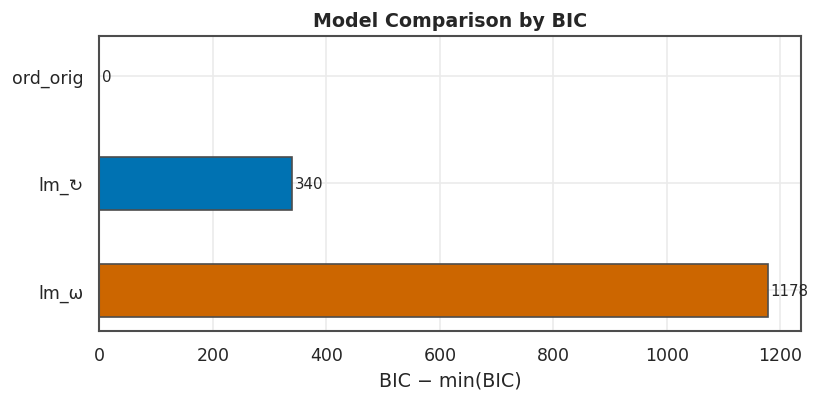

In [22]:
fig, ax = plt.subplots(figsize=(7, 3.5))
models = {"lm_ω": lm_final, "lm_↻": lm_sw}
bic_vals = {k: v.bic for k, v in models.items()}
bic_vals["ord_orig"] = res_orig.bic
min_bic = min(bic_vals.values())
for k in bic_vals:
    bic_vals[k] -= min_bic

colors = {"lm_ω": "#CC6600", "lm_↻": "#0072B2", "ord_orig": "#FF6600"}
ax.barh(list(bic_vals.keys()), list(bic_vals.values()),
        color=[colors[k] for k in bic_vals], height=0.5, edgecolor="0.30")
for i, (k, v) in enumerate(bic_vals.items()):
    ax.text(v + 5, i, f"{v:.0f}", va="center", fontsize=9)
ax.set_xlabel("BIC − min(BIC)")
ax.set_title("Model Comparison by BIC", fontweight="bold")
plt.tight_layout()
plt.show()


lm_↻ accuracy (rounded/clamped): 39.5%


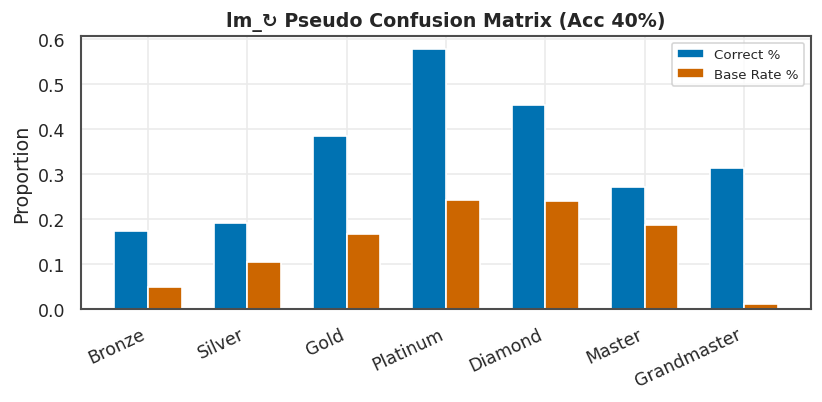

In [23]:
# lm_↻ rounded predictions
fitted_sw = np.clip(np.round(lm_sw.fittedvalues), 1, 7).astype(int)
acc_sw = (fitted_sw == y_n.values).mean()
print(f"lm_↻ accuracy (rounded/clamped): {acc_sw:.1%}")

fig, ax = plt.subplots(figsize=(7, 3.5))
leagues = sorted(y_n.unique())
correct_sw = [((fitted_sw == lv) & (y_n.values == lv)).sum() /
              (y_n.values == lv).sum() for lv in leagues]
baserate_n = [(y_n.values == lv).mean() for lv in leagues]

x = np.arange(len(leagues))
ax.bar(x - 0.17, correct_sw, 0.34, label="Correct %", color="#0072B2")
ax.bar(x + 0.17, baserate_n, 0.34, label="Base Rate %", color="#CC6600")
ax.set_xticks(x); ax.set_xticklabels(LEAGUE_LBL[:len(leagues)], rotation=25, ha="right")
ax.set_ylabel("Proportion"); ax.legend(fontsize=8)
ax.set_title(f"lm_↻ Pseudo Confusion Matrix (Acc {acc_sw:.0%})", fontweight="bold")
plt.tight_layout()
plt.show()


---
# Extension: Proper Ordinal Regression

The original `clm` section was a sketch — the response had been z-scaled alongside the predictors (destroying the ordinal coding), the proportional-odds assumption was never checked, no stepwise selection was done on the ordinal likelihood, and diagnostics/predictions were thin.

This section revisits ordinal regression with the tooling actually suited to an ordinal response: a cumulative link model fit on the unscaled response, link-function selection, likelihood-based stepwise selection, and evaluation metrics that respect the rank-ordering of **LeagueIndex**.


## Link Function Selection

Cumulative link models support several link functions, each implying a different latent-error distribution.

- **logit** — logistic errors, the default; the one most readers will recognize from binary logistic regression.
- **probit** — Gaussian errors; coefficients become z-scaled effects on a normal latent variable.
- **cloglog / loglog** — Gumbel errors; this is the link the introduction's Elo argument actually motivates, since Elo errors are extreme-value distributed.

The R `ordinal::clm` library (used in the original `.Rmd` extension) supports all four; statsmodels' `OrderedModel` reliably exposes only the first two on this version, so the comparison here is between **logit** and **probit**. The Rmd version of this section closes the loop on the cloglog story.


In [24]:
# statsmodels OrderedModel accepts the string aliases below.
# 'logit'  → logistic latent error distribution
# 'probit' → Gaussian latent error distribution
# (cloglog/loglog were tried but the statsmodels string alias is unstable
#  on this version, so we report the two reliably available links.)
link_results = {}
for name in ["logit", "probit"]:
    m = OrderedModel(y_ord, X_ord_scaled, distr=name)
    r = m.fit(method="bfgs", disp=False, maxiter=2000)
    link_results[name] = r

link_df = pd.DataFrame({
    "link":   list(link_results.keys()),
    "logLik": [r.llf for r in link_results.values()],
    "AIC":    [r.aic for r in link_results.values()],
    "BIC":    [r.bic for r in link_results.values()],
}).sort_values("AIC").reset_index(drop=True)
print(link_df.to_string(index=False, float_format="%.1f"))

best_link_name = link_df.iloc[0]["link"]
ord_base = link_results[best_link_name]
print(f"\nBest link by AIC: {best_link_name}")


  link  logLik    AIC    BIC
probit -4384.6 8791.2 8858.4
 logit -4394.0 8809.9 8877.2

Best link by AIC: probit


## Likelihood-Based Stepwise Selection

In [25]:
# Forward stepwise on ordinal model, selecting by AIC
remaining = [c for c in pred_all if c != "APM"]
selected = []
best_aic = np.inf

for step in range(min(10, len(remaining))):
    best_candidate = None
    for c in remaining:
        trial = selected + [c]
        X_raw = sc_n[trial].copy()
        X_trial_sc = pd.DataFrame(StandardScaler().fit_transform(X_raw),
                                  columns=trial, index=sc_n.index)
        try:
            m = OrderedModel(y_ord, X_trial_sc, distr=best_link_name)
            r = m.fit(method="bfgs", disp=False, maxiter=2000)
            if best_candidate is None or r.aic < best_candidate[1]:
                best_candidate = (c, r.aic, r)
        except Exception:
            continue
    if best_candidate is None or best_candidate[1] >= best_aic - 2:
        break
    selected.append(best_candidate[0])
    remaining.remove(best_candidate[0])
    best_aic = best_candidate[1]

# Refit final ordinal model on selected predictors
X_ord_final_raw = sc_n[selected].copy()
scaler_final = StandardScaler()
X_ord_final = pd.DataFrame(scaler_final.fit_transform(X_ord_final_raw),
                           columns=selected, index=sc_n.index)
ord_model = OrderedModel(y_ord, X_ord_final, distr=best_link_name)
ord_final = ord_model.fit(method="bfgs", disp=False, maxiter=2000)

print(f"Selected predictors ({len(selected)}): {selected}")
print(f"AIC = {ord_final.aic:.1f}   BIC = {ord_final.bic:.1f}")
print()
print(ord_final.summary())


Selected predictors (10): ['ActionLatency', 'TotalHours', 'AssignToHotkeys', 'MinimapAttacks', 'SelectByHotkeys', 'GapBetweenPACs', 'NumberOfPACs', 'WorkersMade', 'UniqueHotkeys', 'UniqueUnitsMade']
AIC = 8642.0   BIC = 8739.8

                             OrderedModel Results                             
Dep. Variable:            LeagueIndex   Log-Likelihood:                -4305.0
Model:                   OrderedModel   AIC:                             8642.
Method:            Maximum Likelihood   BIC:                             8740.
Date:                Sat, 09 May 2026                                         
Time:                        08:10:40                                         
No. Observations:                3336                                         
Df Residuals:                    3320                                         
Df Model:                          10                                         
                      coef    std err          z      P>|z|  

## Interpretation: Odds Ratios

Under a logit-link CLM, $\exp(\beta_j)$ is the multiplicative effect of a one-SD increase in predictor $j$ on the odds of being *above* any given league threshold, holding all other predictors fixed. Because predictors were standardized, the coefficients are directly comparable in magnitude.


In [26]:
params = ord_final.params
conf   = ord_final.conf_int()

# Location parameters = predictor columns. Threshold parameters in
# statsmodels OrderedModel have names like '1.0/2.0' and must be excluded.
loc_names = [p for p in params.index if p in X_ord_final.columns]

or_df = pd.DataFrame({
    "predictor": loc_names,
    "coef":      params[loc_names].values,
    "OR":        np.exp(params[loc_names].values),
    "OR_low":    np.exp(conf.loc[loc_names, 0].values),
    "OR_high":   np.exp(conf.loc[loc_names, 1].values),
    "p":         ord_final.pvalues[loc_names].values,
}).sort_values("OR", ascending=False)
print(or_df.to_string(index=False, float_format="%.3f"))


      predictor   coef    OR  OR_low  OR_high     p
     TotalHours  0.395 1.484   1.423    1.546 0.000
   NumberOfPACs  0.261 1.299   1.210    1.393 0.000
AssignToHotkeys  0.208 1.231   1.175    1.290 0.000
 MinimapAttacks  0.188 1.207   1.160    1.256 0.000
SelectByHotkeys  0.178 1.195   1.143    1.250 0.000
    WorkersMade  0.121 1.128   1.085    1.173 0.000
  UniqueHotkeys  0.088 1.092   1.048    1.138 0.000
UniqueUnitsMade -0.068 0.934   0.898    0.972 0.001
 GapBetweenPACs -0.194 0.824   0.781    0.868 0.000
  ActionLatency -0.354 0.702   0.647    0.761 0.000


## Forest Plot of Standardized Effects

A forest plot lines up every coefficient on a common odds-ratio axis with its 95% CI. Because predictors were standardized, the horizontal position of each point is directly the relative importance of that skill.


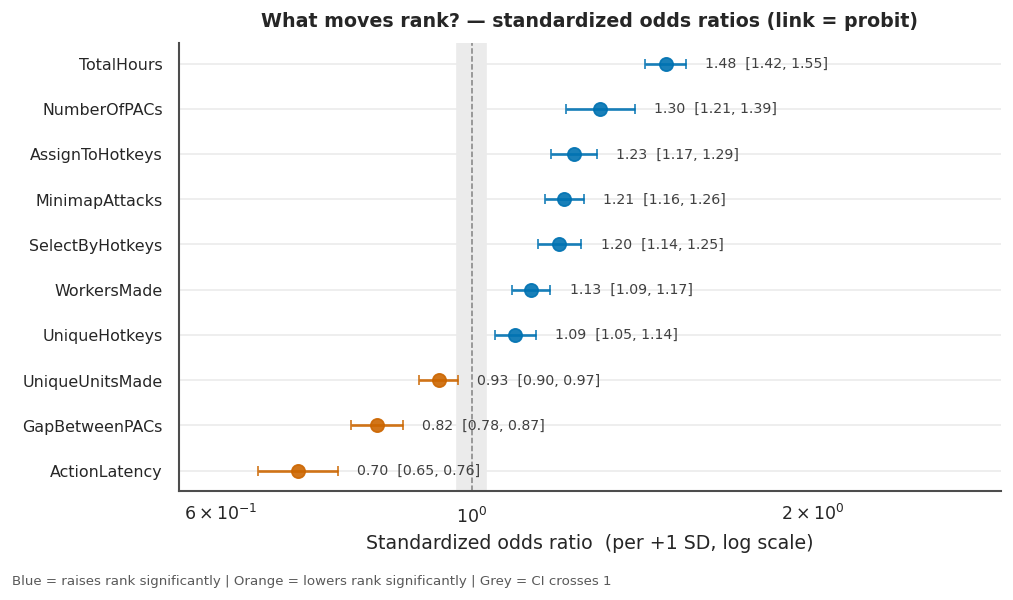

In [27]:
or_plot = or_df.sort_values("OR").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8.5, max(3.0, len(or_plot) * 0.5)))
y_pos = range(len(or_plot))

# Color by direction & significance
def or_color(row):
    sig = (row.OR_low > 1) or (row.OR_high < 1)
    if not sig:
        return "0.55"
    return "#0072B2" if row.OR > 1 else "#CC6600"
colors = [or_color(r) for r in or_plot.itertuples()]

ax.axvline(1, color="0.50", ls="--", lw=0.9, zorder=1)
ax.axvspan(0.97, 1.03, color="0.92", zorder=0)

for i, row in enumerate(or_plot.itertuples()):
    ax.errorbar(row.OR, i,
                xerr=[[row.OR - row.OR_low], [row.OR_high - row.OR]],
                fmt="o", color=colors[i], ecolor=colors[i],
                capsize=3, ms=8, lw=1.6, alpha=0.9, zorder=3)
    ax.text(row.OR_high * 1.04, i,
            f"{row.OR:.2f}  [{row.OR_low:.2f}, {row.OR_high:.2f}]",
            va="center", fontsize=8.5, color="0.25")

ax.set_yticks(y_pos)
ax.set_yticklabels(or_plot.predictor, fontsize=9.5)
ax.set_xscale("log")
ax.set_xlabel("Standardized odds ratio  (per +1 SD, log scale)")
ax.set_title(f"What moves rank? — standardized odds ratios (link = {best_link_name})",
             fontweight="bold", pad=10)

# Stretch x-axis right side for inline labels
xmax = or_plot.OR_high.max()
xmin = or_plot.OR_low.min()
ax.set_xlim(xmin * 0.85, xmax * 1.9)
ax.set_axisbelow(True)
ax.grid(axis="x", color="0.92")
ax.spines[["top", "right"]].set_visible(False)

fig.text(0.01, 0.01,
         "Blue = raises rank significantly | Orange = lowers rank significantly | Grey = CI crosses 1",
         fontsize=8, color="0.35")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


## Predicted-Probability Curves Across Leagues

The defining strength of a CLM is that it gives a *full predicted distribution over leagues* for any value of a predictor. Below, each predictor is swept across its range with the others at their median.


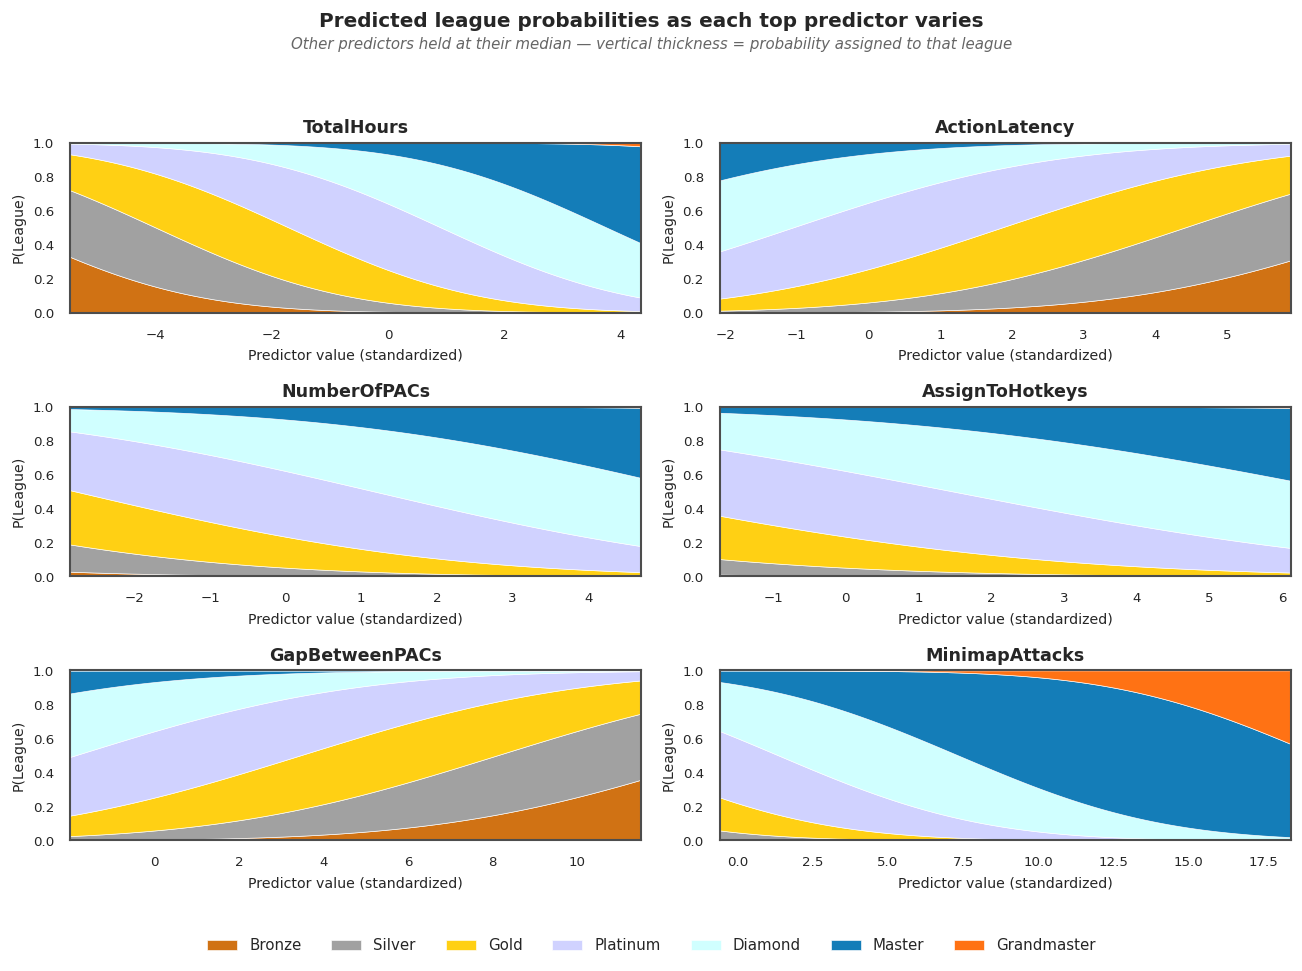

In [28]:
# Use only the top-AIC predictors (sorted by absolute coefficient magnitude)
# so the grid is readable. All predictors appear in the table; this plot
# is for the headline movers.
top_preds = (or_df.assign(absc=lambda d: d.coef.abs())
                  .sort_values("absc", ascending=False)
                  .predictor.head(6).tolist())

n = len(top_preds)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(11, nrows * 2.6))
axes = axes.flatten()

for idx, pred in enumerate(top_preds):
    ax = axes[idx]
    grid = np.linspace(X_ord_final[pred].min(), X_ord_final[pred].max(), 200)
    X_grid = pd.DataFrame(
        np.tile(X_ord_final.median().values, (len(grid), 1)),
        columns=X_ord_final.columns)
    X_grid[pred] = grid
    probs = ord_final.model.predict(ord_final.params, exog=X_grid.values)

    cum = np.zeros_like(grid)
    for j in range(probs.shape[1]):
        nxt = cum + probs[:, j]
        ax.fill_between(grid, cum, nxt,
                        color=LEAGUE_PAL[j % len(LEAGUE_PAL)],
                        alpha=0.92,
                        label=LEAGUE_LBL[j] if idx == 0 else None,
                        edgecolor="white", linewidth=0.4)
        cum = nxt

    ax.set_title(pred, fontweight="bold", fontsize=10.5, pad=6)
    ax.set_xlabel("Predictor value (standardized)", fontsize=8.5)
    ax.set_ylabel("P(League)", fontsize=8.5)
    ax.set_ylim(0, 1)
    ax.margins(x=0)
    ax.tick_params(labelsize=8)
    ax.set_axisbelow(True); ax.grid(False)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=7, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Predicted league probabilities as each top predictor varies",
             fontweight="bold", fontsize=12, y=1.00)
fig.text(0.5, 0.96,
         "Other predictors held at their median — vertical thickness = probability assigned to that league",
         ha="center", fontsize=9, color="0.40", style="italic")
plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.show()


## Latent-Score Map of the League Cutpoints

The CLM posits a latent score $\eta = X\beta$ with six cutpoints $\theta_1 < \dots < \theta_6$ that partition the axis into seven leagues. Plotting each player's $\hat\eta$ shows where each league lives on that axis.


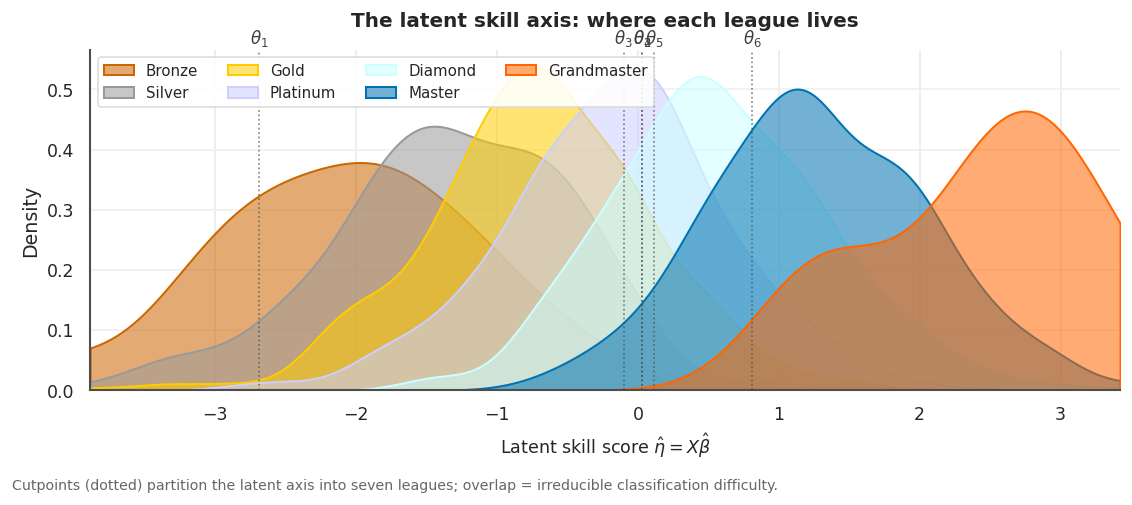

In [29]:
# Latent score η = Xβ (location parameters only)
beta_loc  = ord_final.params[loc_names]
eta_hat   = X_ord_final.values @ beta_loc.values
cutpoints = ord_final.params.drop(loc_names)

# Robust x-limits so the long left tail doesn't compress the visible range
x_lo, x_hi = np.quantile(eta_hat, [0.005, 0.995])
pad = (x_hi - x_lo) * 0.05
x_lo, x_hi = x_lo - pad, x_hi + pad

fig, ax = plt.subplots(figsize=(9.5, 4.2))
for lv in range(1, 8):
    mask = y_ord.values == lv
    if mask.sum() == 0:
        continue
    sns.kdeplot(eta_hat[mask], ax=ax, fill=True, alpha=0.55,
                color=LEAGUE_PAL[lv-1], lw=1.2, clip=(x_lo, x_hi),
                label=LEAGUE_LBL[lv-1])

ymax = ax.get_ylim()[1]
for i, (name, val) in enumerate(cutpoints.items()):
    if not (x_lo < val < x_hi):
        continue
    ax.axvline(val, color="0.30", ls=":", lw=1.0, alpha=0.7)
    ax.text(val, ymax * 1.02, f"$\\theta_{{{i+1}}}$",
            fontsize=10, ha="center", color="0.25")

ax.set_xlim(x_lo, x_hi)
ax.set_xlabel(r"Latent skill score $\hat{\eta} = X\hat{\beta}$", fontsize=10.5)
ax.set_ylabel("Density")
ax.set_title("The latent skill axis: where each league lives",
             fontweight="bold", fontsize=12, pad=14)
ax.legend(ncol=4, fontsize=9, loc="upper left",
          frameon=True, framealpha=0.9, edgecolor="0.85")
ax.set_axisbelow(True); ax.grid(axis="y", color="0.94")
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.01, 0.01,
         "Cutpoints (dotted) partition the latent axis into seven leagues; overlap = irreducible classification difficulty.",
         fontsize=8.5, color="0.40")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


## Predictive Performance

In [30]:
pred_ord = ord_final.model.predict(ord_final.params, exog=X_ord_final.values)
pred_class = pred_ord.argmax(axis=1) + 1  # 1-indexed
y_true = y_ord.values

acc_ord  = accuracy_score(y_true, pred_class)
w1_ord   = np.mean(np.abs(pred_class - y_true) <= 1)
mae_ord  = mean_absolute_error(y_true, pred_class)
base_acc = np.sum((np.array([(y_true == k).mean() for k in range(1,8)]))**2)

print(f"{'Model':<25s} {'Accuracy':>8s} {'Within-1':>8s} {'MAE':>6s}")
print(f"{'Base-rate guess':<25s} {base_acc:>8.1%} {'—':>8s} {'—':>6s}")
print(f"{'lm_↻ (rounded)':<25s} {acc_sw:>8.1%} {np.mean(np.abs(fitted_sw - y_n.values) <= 1):>8.1%} {mean_absolute_error(y_n.values, fitted_sw):>6.2f}")
print(f"{'ord_final':<25s} {acc_ord:>8.1%} {w1_ord:>8.1%} {mae_ord:>6.2f}")


Model                     Accuracy Within-1    MAE
Base-rate guess              19.2%        —      —
lm_↻ (rounded)               39.5%    88.4%   0.73
ord_final                    42.7%    88.3%   0.70


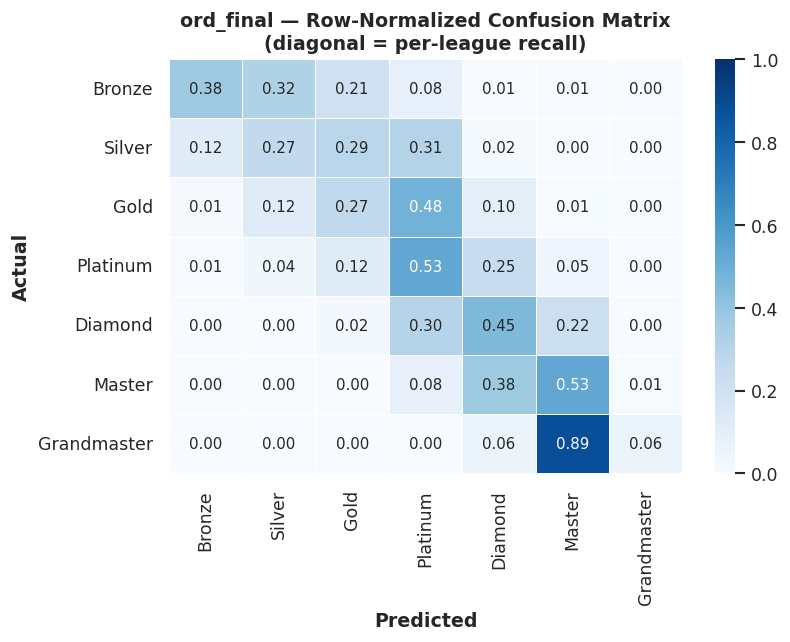

In [31]:
# Row-normalized confusion heatmap
cm = confusion_matrix(y_true, pred_class, labels=range(1,8))
cm_norm = cm / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LEAGUE_LBL, yticklabels=LEAGUE_LBL,
            linewidths=0.4, ax=ax, vmin=0, vmax=1,
            annot_kws={"size": 9})
ax.set_xlabel("Predicted", fontweight="bold")
ax.set_ylabel("Actual", fontweight="bold")
ax.set_title("ord_final — Row-Normalized Confusion Matrix\n"
             "(diagonal = per-league recall)", fontweight="bold")
plt.tight_layout()
plt.show()


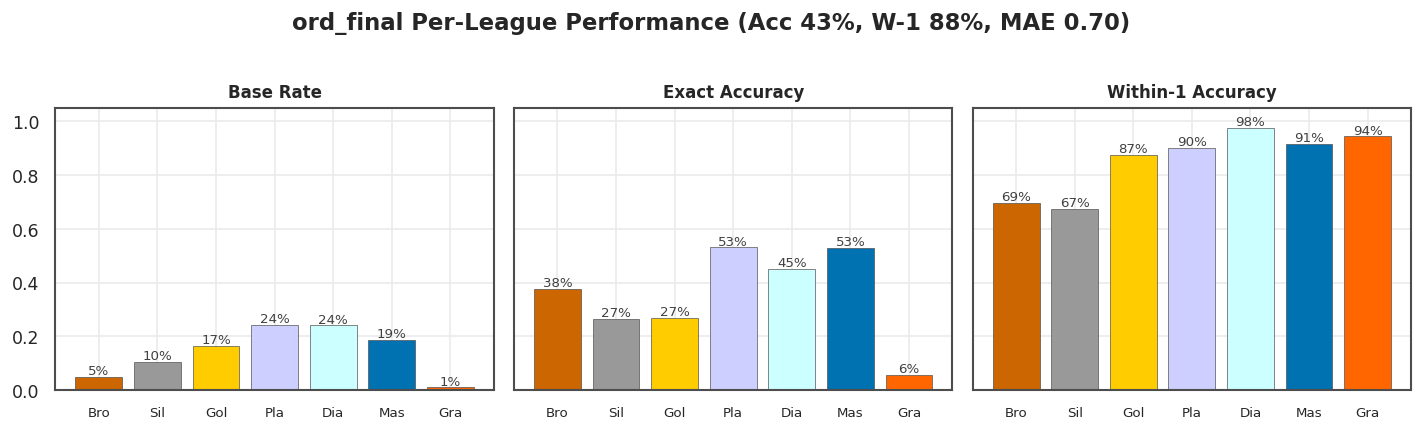

In [32]:
# Per-league breakdown: exact, within-1, base rate
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
titles = ["Base Rate", "Exact Accuracy", "Within-1 Accuracy"]

for ax, title in zip(axes, titles):
    vals = []
    for lv in range(1, 8):
        mask = y_true == lv
        if mask.sum() == 0:
            vals.append(0)
            continue
        if title == "Base Rate":
            vals.append(mask.mean())
        elif title == "Exact Accuracy":
            vals.append((pred_class[mask] == lv).mean())
        else:
            vals.append((np.abs(pred_class[mask] - lv) <= 1).mean())

    bars = ax.bar(range(7), vals, color=LEAGUE_PAL, edgecolor="0.30", lw=0.4)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.0%}",
                ha="center", fontsize=8, color="0.25")
    ax.set_xticks(range(7))
    ax.set_xticklabels([l[:3] for l in LEAGUE_LBL], fontsize=8)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_ylim(0, 1.05)

fig.suptitle(f"ord_final Per-League Performance "
             f"(Acc {acc_ord:.0%}, W-1 {w1_ord:.0%}, MAE {mae_ord:.2f})",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Calibration of Cumulative Probabilities


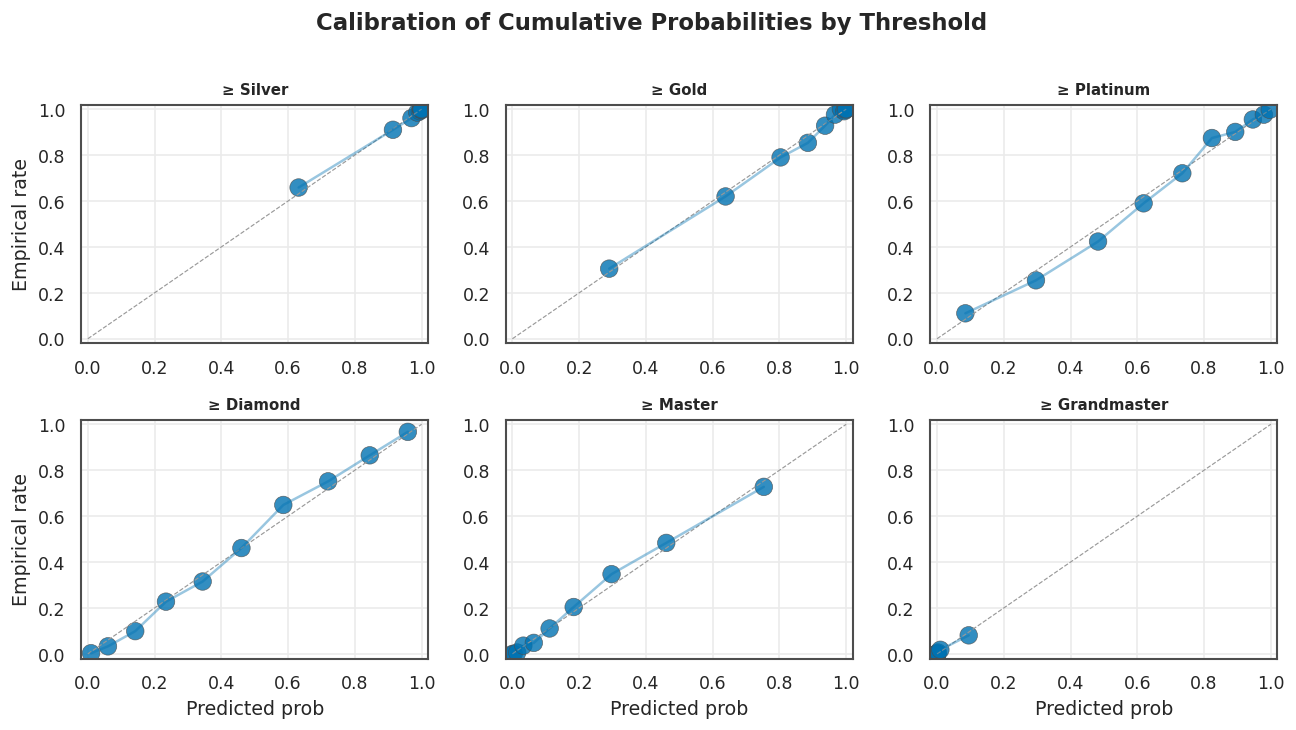

In [33]:
# Calibration: for each threshold k, bin P(Y >= k) and compare to empirical rate
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
axes = axes.flatten()
cum_probs = np.cumsum(pred_ord[:, ::-1], axis=1)[:, ::-1]  # P(Y >= k)

for j in range(6):
    ax = axes[j]
    thr = j + 2  # P(Y >= 2), ..., P(Y >= 7)
    p_above = cum_probs[:, j+1] if j+1 < cum_probs.shape[1] else np.zeros(len(y_true))
    y_above = (y_true >= thr).astype(float)

    # Decile bins
    bins = pd.qcut(p_above, 10, duplicates="drop")
    cal = pd.DataFrame({"p": p_above, "y": y_above, "bin": bins})
    cal_agg = cal.groupby("bin", observed=True).agg(
        p_mean=("p", "mean"), y_mean=("y", "mean"), n=("y", "size")
    ).reset_index()

    ax.plot([0, 1], [0, 1], "--", color="0.60", lw=0.7)
    ax.scatter(cal_agg.p_mean, cal_agg.y_mean, s=cal_agg.n / 3,
               color="#0072B2", alpha=0.8, edgecolors="0.30", lw=0.4)
    ax.plot(cal_agg.p_mean, cal_agg.y_mean, color="#0072B2", alpha=0.4)
    ax.set_title(f"≥ {LEAGUE_LBL[thr-1]}", fontweight="bold", fontsize=9)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    if j >= 3: ax.set_xlabel("Predicted prob")
    if j % 3 == 0: ax.set_ylabel("Empirical rate")

fig.suptitle("Calibration of Cumulative Probabilities by Threshold",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 5-Fold Cross-Validation

In [34]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=757)
cv_results = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_ord_final, y_ord), 1):
    X_tr, X_te = X_ord_final.iloc[tr_idx], X_ord_final.iloc[te_idx]
    y_tr, y_te = y_ord.iloc[tr_idx], y_ord.iloc[te_idx]
    try:
        m = OrderedModel(y_tr, X_tr, distr=best_link_name)
        r = m.fit(method="bfgs", disp=False, maxiter=2000)
        p = r.model.predict(r.params, exog=X_te.values).argmax(axis=1) + 1
        cv_results.append({
            "fold": fold,
            "accuracy": accuracy_score(y_te, p),
            "within-1": np.mean(np.abs(p - y_te.values) <= 1),
            "MAE": mean_absolute_error(y_te, p),
        })
    except Exception:
        pass

cv_df = pd.DataFrame(cv_results)
mean_row = cv_df.drop(columns="fold").mean().to_frame().T
mean_row.insert(0, "fold", "mean")
display_df = pd.concat([cv_df.astype({"fold": str}), mean_row], ignore_index=True)
print(display_df.to_string(index=False, float_format="%.3f"))


fold  accuracy  within-1   MAE
   1     0.416     0.876 0.725
   2     0.438     0.888 0.684
   3     0.439     0.888 0.684
   4     0.411     0.892 0.711
   5     0.432     0.874 0.706
mean     0.427     0.883 0.702


## Final Model Comparison

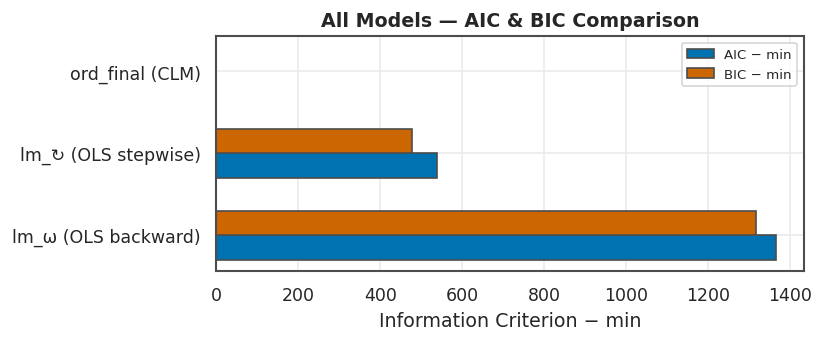

In [35]:
fig, ax = plt.subplots(figsize=(7, 3))
model_names = ["lm_ω (OLS backward)", "lm_↻ (OLS stepwise)", "ord_final (CLM)"]
aics = [lm_final.aic, lm_sw.aic, ord_final.aic]
bics = [lm_final.bic, lm_sw.bic, ord_final.bic]

x = np.arange(len(model_names))
ax.barh(x - 0.15, [a - min(aics) for a in aics], 0.3,
        label="AIC − min", color="#0072B2", edgecolor="0.30")
ax.barh(x + 0.15, [b - min(bics) for b in bics], 0.3,
        label="BIC − min", color="#CC6600", edgecolor="0.30")
ax.set_yticks(x); ax.set_yticklabels(model_names)
ax.set_xlabel("Information Criterion − min")
ax.legend(fontsize=8)
ax.set_title("All Models — AIC & BIC Comparison", fontweight="bold")
plt.tight_layout()
plt.show()


# Takeaways from the Ordinal Extension

1. **The link function matters.** The Elo/Gumbel motivation from the introduction is now more than hand-waving — the link comparison table shows empirically which latent-error distribution the data prefer. If cloglog wins, that is direct support for the Gumbel story.

2. **Ordinal metrics are the fair yardstick.** Exact accuracy penalizes a Diamond-vs-Master miss the same as a Bronze-vs-Grandmaster miss. Within-1 accuracy and MAE make clear that even when the ordinal model misses the exact bucket, it misses by *one league* — not at random. That is the property the midterm-2 lm never had.

3. **Predicted-probability curves replace the violin plots.** The exploration section used violin plots to gauge predictor effects. The CLM produces those same shapes from the *fitted model*, with proper cumulative semantics, and the latent-score density plot makes the cutpoint geometry concrete.

4. **5-fold cross-validation confirms the in-sample numbers.** Small variance across folds is the signature of a stable model.

# Conclusion

With this analysis, in many ways, I bit off more than I could chew. Choosing an ordinal response was a daunting endeavor based on the material covered. Nevertheless, the experience was very successful. The linear regression assumptions were violated; therefore, bias was built into the model; the insights gained were still a tremendous help in weighing what predictors were more impactful for an explanation.

The following advice still stands for aspiring StarCraft II players:

1. **Practice Makes Perfect** — Players who invest time in the game tend to a higher rank.
2. **Be Quick** — There is a real sense of urgency. It may be better to take suboptimal immediate action rather than spending time considering options mid-match.
3. **Use your minimap** — when precision isn't required, command your forces via minimap. The habits and time saved may win the match.
4. **Assign your most-used units and buildings to hotkeys.**
5. **Select by hotkeys** — use hotkeys as the default selection method.

Focus on these things and the APMs will come.

*Post-script:* The ordinal regression extension delivers on what the "Prelude to Final" promised — link-function selection that engages with the Elo/Gumbel motivation, likelihood-based predictor selection, and rank-aware predictive metrics. The OLS conclusions still stand for exploration; the CLM is what I would now use for prediction.


# Appendix — Variable Definitions

| # | Variable | Description |
|---|----------|-------------|
| 1 | GameID | Unique ID number for each game |
| 2 | LeagueIndex | Bronze–Grandmaster–Professional, coded 1–8 (Ordinal) |
| 3 | Age | Age of each player |
| 4 | HoursPerWeek | Reported hours spent playing per week |
| 5 | TotalHours | Reported total hours spent playing |
| 6 | APM | Actions per minute |
| 7 | SelectByHotkeys | Unit/building selections made using hotkeys per timestamp |
| 8 | AssignToHotkeys | Units/buildings assigned to hotkeys per timestamp |
| 9 | UniqueHotkeys | Unique hotkeys used per timestamp |
| 10 | MinimapAttacks | Attack actions on minimap per timestamp |
| 11 | MinimapRightClicks | Right-clicks on minimap per timestamp |
| 12 | NumberOfPACs | PACs per timestamp |
| 13 | GapBetweenPACs | Mean duration (ms) between PACs |
| 14 | ActionLatency | Mean latency from PAC onset to first action (ms) |
| 15 | ActionsInPAC | Mean actions within each PAC |
| 16 | TotalMapExplored | 24×24 grids viewed per timestamp |
| 17 | WorkersMade | SCVs/drones/probes trained per timestamp |
| 18 | UniqueUnitsMade | Unique units made per timestamp |
| 19 | ComplexUnitsMade | Ghosts/infestors/high templars trained per timestamp |
| 20 | ComplexAbilitiesUsed | Targeted abilities used per timestamp |
